# EcoVision — End-to-End ML Pipeline (Observed Data Only)

Goal: Train a **reproducible** model that predicts `risk` (Low / Moderate / High) using **only observed environmental variables**.

Important modeling choice:
- Training uses only observed features: `aqi`, `temperature`, `humidity`
- Age/health are **not** used for model fitting (prevents synthetic leakage)
- Age/health can be applied later as **transparent rule-based adjustments** at inference time (see Deployment section)

Note for interviews (important):
- Here, `risk` is derived from an AQI-like index, so `aqi` will be a very strong signal.
- To make this more “real-world”, you can: (1) use official AQI breakpoints, (2) predict **future** AQI/risk (time-series), or (3) train on pollutant concentrations directly.

## What this notebook does (industry-style)
1. Problem definition + success metrics
2. Data collection (UCI Air Quality) and dataset build (`best_combo_dataset.csv`)
3. Data cleaning + validation checks
4. EDA (summary + plots)
5. Feature setup (baseline features, optional engineered features)
6. Model selection (cross-validated comparison of multiple models)
7. Training (train/validation split)
8. Evaluation (macro F1, accuracy, confusion matrix)
9. Tuning (hyperparameter search for the best candidate)
10. Model saving (model `.pkl` + metadata `.json`)
11. Deployment snippets (Flask / Streamlit-friendly)
12. Testing checklist + next improvements

## Outputs (saved under `Backend/model/`)
- `dataset/best_combo_dataset.csv`
- `aqi_model.pkl`
- `aqi_model.meta.json`

References:
- UCI Air Quality: https://archive.ics.uci.edu/dataset/360/air+quality
- OpenWeather AQI categories: https://openweathermap.org/api/air-pollution

In [1]:
# Step 0 — Install dependencies (run once per environment)
%pip -q install pandas numpy scikit-learn matplotlib seaborn joblib requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Step 0 — Imports + configuration (reproducible paths + helpers)
from __future__ import annotations

from pathlib import Path
import io
import zipfile
import hashlib
import json
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import joblib
import sklearn

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.2

UCI_AIR_QUALITY_ZIP_URL = "https://archive.ics.uci.edu/static/public/360/air+quality.zip"

FEATURES = ["aqi", "temperature", "humidity"]
TARGET = "risk"


def find_repo_root(start: Path | None = None) -> Path:
    """Find the repo root by searching upward for common markers."""
    start = start or Path.cwd()
    markers = ["Backend", "frontend", "package.json"]
    for p in [start] + list(start.parents):
        if all((p / m).exists() for m in markers):
            return p
    return start


REPO_ROOT = find_repo_root()
BACKEND_DIR = REPO_ROOT / "Backend"
MODEL_DIR = BACKEND_DIR / "model"
DATASET_DIR = MODEL_DIR / "dataset"
DATA_DIR = MODEL_DIR / "data"
RAW_DIR = DATA_DIR / "raw"

for d in [DATASET_DIR, RAW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_CSV = RAW_DIR / "AirQualityUCI.csv"
DATASET_PATH = DATASET_DIR / "best_combo_dataset.csv"

MODEL_PATH = MODEL_DIR / "aqi_model.pkl"              # used by Backend/app.py
META_PATH = MODEL_DIR / "aqi_model.meta.json"


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def download_uci_air_quality(*, out_dir: Path = RAW_DIR) -> Path:
    """Download & extract the UCI Air Quality dataset if missing."""
    out_dir.mkdir(parents=True, exist_ok=True)
    csv_path = out_dir / "AirQualityUCI.csv"

    if csv_path.exists():
        return csv_path

    resp = requests.get(UCI_AIR_QUALITY_ZIP_URL, timeout=60)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        zf.extractall(out_dir)

    if not csv_path.exists():
        raise FileNotFoundError(f"Expected {csv_path} after extracting UCI zip")

    return csv_path


def build_best_combo_dataset(raw_csv_path: Path) -> pd.DataFrame:
    """Create the observed-only training dataset (aqi, temperature, humidity, risk)."""
    df_raw = pd.read_csv(raw_csv_path, sep=";", decimal=",")

    # Drop empty trailing columns that appear in the UCI CSV
    df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("^Unnamed")]
    df_raw = df_raw.drop(columns=[c for c in df_raw.columns if str(c).strip() == ""], errors="ignore")

    # Convert numeric columns and replace UCI missing sentinel (-200)
    for col in df_raw.columns:
        if col not in ["Date", "Time"]:
            df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

    df_raw = df_raw.replace(-200, np.nan)

    required_cols = ["T", "RH", "CO(GT)", "NO2(GT)", "NOx(GT)", "C6H6(GT)"]
    df = df_raw.dropna(subset=required_cols).copy()

    # Build AQI-like 1..5 index from observed pollutant columns
    pollution_cols = ["CO(GT)", "NO2(GT)", "NOx(GT)", "C6H6(GT)"]
    norm = (df[pollution_cols] - df[pollution_cols].min()) / (df[pollution_cols].max() - df[pollution_cols].min())
    pollution_index = norm.mean(axis=1).clip(0, 1)
    aqi = (1 + 4 * pollution_index).round().astype(int).clip(1, 5)

    temperature = df["T"].astype(float)
    humidity = df["RH"].astype(float)

    # Environmental risk label from AQI category (0=Low, 1=Moderate, 2=High)
    risk = np.select([aqi <= 2, aqi == 3, aqi >= 4], [0, 1, 2]).astype(int)

    combo_df = (
        pd.DataFrame(
            {
                "aqi": aqi,
                "temperature": temperature.round(2),
                "humidity": humidity.round(2),
                "risk": risk,
            }
        )
        .dropna()
        .reset_index(drop=True)
    )

    return combo_df


print("Repo root:", REPO_ROOT)
print("Raw CSV:", RAW_CSV)
print("Dataset:", DATASET_PATH)
print("Model out:", MODEL_PATH)
print("Python:", platform.python_version(), "| sklearn:", sklearn.__version__)

Repo root: C:\Users\PRERNA\OneDrive\Desktop\Ecovision final\ecovision-main\ecovision-main
Raw CSV: C:\Users\PRERNA\OneDrive\Desktop\Ecovision final\ecovision-main\ecovision-main\Backend\model\data\raw\AirQualityUCI.csv
Dataset: C:\Users\PRERNA\OneDrive\Desktop\Ecovision final\ecovision-main\ecovision-main\Backend\model\dataset\best_combo_dataset.csv
Model out: C:\Users\PRERNA\OneDrive\Desktop\Ecovision final\ecovision-main\ecovision-main\Backend\model\aqi_model.pkl
Python: 3.13.3 | sklearn: 1.8.0


In [3]:
# Step 2–3 — Data collection + cleaning + dataset build
# If you already have `Backend/model/dataset/best_combo_dataset.csv`, this will just load it.

REBUILD_DATASET = False

if (not DATASET_PATH.exists()) or REBUILD_DATASET:
    raw_csv_path = download_uci_air_quality()
    combo_df = build_best_combo_dataset(raw_csv_path)

    DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
    combo_df.to_csv(DATASET_PATH, index=False)

    print("Saved dataset:", DATASET_PATH.resolve())
else:
    combo_df = pd.read_csv(DATASET_PATH)
    print("Loaded dataset:", DATASET_PATH.resolve())

# Basic validation
required_cols = FEATURES + [TARGET]
missing = set(required_cols) - set(combo_df.columns)
if missing:
    raise ValueError(f"Dataset missing required columns: {sorted(missing)}")

combo_df = combo_df[required_cols].copy()
for col in required_cols:
    combo_df[col] = pd.to_numeric(combo_df[col], errors="coerce")

combo_df = combo_df.dropna().reset_index(drop=True)
combo_df[TARGET] = combo_df[TARGET].astype(int)

print("Shape:", combo_df.shape)
display(combo_df.head())

Loaded dataset: C:\Users\PRERNA\OneDrive\Desktop\Ecovision final\ecovision-main\ecovision-main\Backend\model\dataset\best_combo_dataset.csv
Shape: (6941, 4)


,aqi,temperature,humidity,risk
0,2,13.6,48.9,0
1,2,13.3,47.7,0
2,2,11.9,54.0,0
3,2,11.0,60.0,0
4,2,11.2,59.6,0


In [4]:
# Step 4 — EDA: structure and summary
print("Dataset shape:", combo_df.shape)

print("\nDtypes:")
print(combo_df.dtypes)

print("\nMissing values:")
print(combo_df.isna().sum())

print("\nDescribe:")
display(combo_df.describe())

print("\nRisk distribution (counts):")
dist = combo_df[TARGET].value_counts().sort_index()
display(dist)

print("\nRisk distribution (percent):")
display(((dist / dist.sum()) * 100).round(2).rename("percent"))

print("\nDuplicate rows:", int(combo_df.duplicated().sum()))

Dataset shape: (6941, 4)

Dtypes:
aqi              int64
temperature    float64
humidity       float64
risk             int64
dtype: object

Missing values:
aqi            0
temperature    0
humidity       0
risk           0
dtype: int64

Describe:


,aqi,temperature,humidity,risk
count,6941.000000,6941.000000,6941.000000,6941.000000
mean,1.848437,17.755323,48.881905,0.102003
std,0.585186,8.844909,17.433193,0.318449
min,1.000000,-1.900000,9.200000,0.000000
25%,1.000000,11.200000,35.300000,0.000000
50%,2.000000,16.800000,49.200000,0.000000
75%,2.000000,23.700000,62.200000,0.000000
max,4.000000,44.600000,88.700000,2.000000



Risk distribution (counts):


risk
0    6267
1     640
2      34
Name: count, dtype: int64


Risk distribution (percent):


risk
0    90.29
1     9.22
2     0.49
Name: percent, dtype: float64


Duplicate rows: 84


In [5]:
# Step 5 — Feature setup (keep backend-compatible by default)
# The deployed Flask backend currently expects ONLY: aqi, temperature, humidity
# So we keep engineered features OFF by default.

BASE_FEATURES = FEATURES.copy()


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Optional feature engineering (derived only from observed variables)."""
    out = df.copy()
    out["temp_x_humidity"] = out["temperature"] * out["humidity"]
    out["aqi_x_temp"] = out["aqi"] * out["temperature"]
    return out


USE_ENGINEERED_FEATURES = False

model_df = combo_df.copy()
if USE_ENGINEERED_FEATURES:
    model_df = add_engineered_features(model_df)
    feature_cols = BASE_FEATURES + ["temp_x_humidity", "aqi_x_temp"]
else:
    feature_cols = BASE_FEATURES

X = model_df[feature_cols]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Features used:", feature_cols)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

Features used: ['aqi', 'temperature', 'humidity']
Train shape: (5552, 3) | Test shape: (1389, 3)
Train class balance:
risk
0    0.903
1    0.092
2    0.005
Name: proportion, dtype: float64


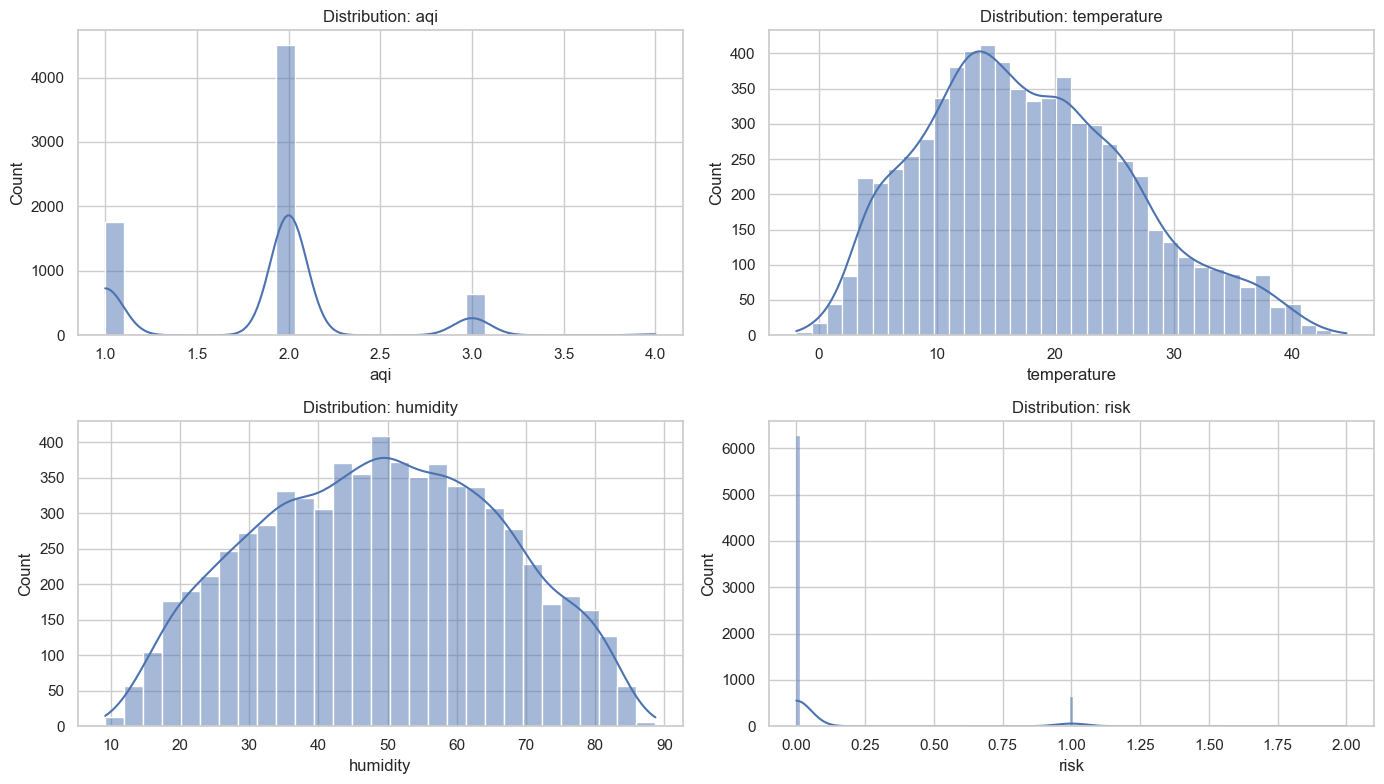

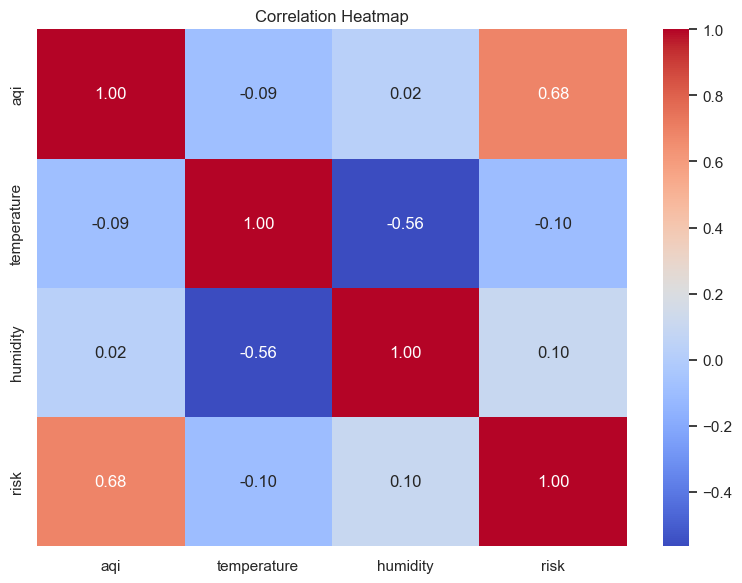

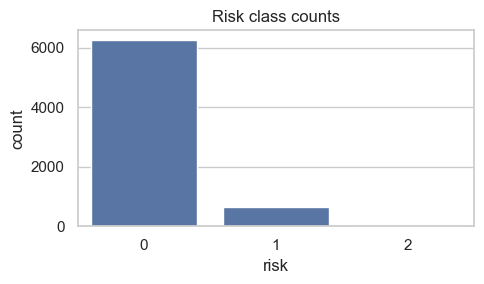

In [6]:
# Step 4 — EDA: visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols = ["aqi", "temperature", "humidity", TARGET]

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(combo_df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(combo_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Simple class balance plot
plt.figure(figsize=(5, 3))
sns.countplot(x=TARGET, data=combo_df)
plt.title("Risk class counts")
plt.tight_layout()
plt.show()

CV results (sorted by macro F1):


,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std
0,LogReg,1.000000,0.000000,1.000000,0.000000
1,RandomForest,1.000000,0.000000,1.000000,0.000000
2,ExtraTrees,1.000000,0.000000,1.000000,0.000000
3,DummyMostFrequent,0.902918,0.000345,0.316327,0.000064


Selected best candidate: LogReg

Tuning complete.
Best CV macro F1: 1.0
Best params: {'clf__C': 0.01}

=== Hold-out Test Metrics ===
Accuracy : 1.0000
Macro F1 : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1254
           1     1.0000    1.0000    1.0000       128
           2     1.0000    1.0000    1.0000         7

    accuracy                         1.0000      1389
   macro avg     1.0000    1.0000    1.0000      1389
weighted avg     1.0000    1.0000    1.0000      1389



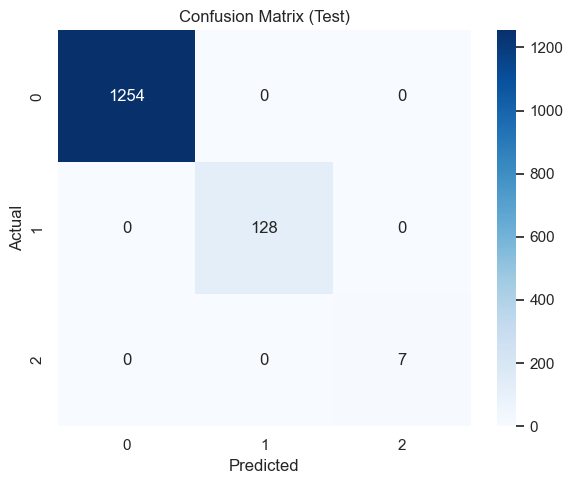

,avg_abs_coef
aqi,1.768894
humidity,0.092765
temperature,0.074612



Best model chosen: Pipeline


In [7]:
# Step 6–9 — Model selection (CV) → tuning → final evaluation → choose best model

scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "DummyMostFrequent": DummyClassifier(strategy="most_frequent"),
    "LogReg": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=600,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
}

# --- 6) Model selection using CV on TRAIN split only ---
rows: list[dict] = []
for name, estimator in candidates.items():
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )

    rows.append(
        {
            "model": name,
            "cv_accuracy_mean": float(np.mean(scores["test_accuracy"])),
            "cv_accuracy_std": float(np.std(scores["test_accuracy"])),
            "cv_f1_macro_mean": float(np.mean(scores["test_f1_macro"])),
            "cv_f1_macro_std": float(np.std(scores["test_f1_macro"])),
        }
    )

cv_results = pd.DataFrame(rows).sort_values("cv_f1_macro_mean", ascending=False).reset_index(drop=True)
print("CV results (sorted by macro F1):")
display(cv_results)

best_name = str(cv_results.loc[0, "model"])
best_estimator = candidates[best_name]
print("Selected best candidate:", best_name)

# --- 9) Tuning (small, practical search) ---
DO_TUNING = True

search = None
if DO_TUNING and best_name == "RandomForest":
    param_dist = {
        "n_estimators": [200, 300, 500, 800],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
    }

    search = RandomizedSearchCV(
        estimator=best_estimator,
        param_distributions=param_dist,
        n_iter=20,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )

elif DO_TUNING and best_name == "ExtraTrees":
    param_dist = {
        "n_estimators": [300, 600, 900],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
    }

    search = RandomizedSearchCV(
        estimator=best_estimator,
        param_distributions=param_dist,
        n_iter=20,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )

elif DO_TUNING and best_name == "LogReg":
    param_dist = {
        "clf__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
    }

    search = RandomizedSearchCV(
        estimator=best_estimator,
        param_distributions=param_dist,
        n_iter=7,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )

if search is not None:
    search.fit(X_train, y_train)
    final_model = search.best_estimator_
    best_params = search.best_params_
    print("\nTuning complete.")
    print("Best CV macro F1:", float(search.best_score_))
    print("Best params:", best_params)
else:
    final_model = best_estimator
    best_params = getattr(final_model, "get_params", lambda: {})()

# --- 7–8) Final training + evaluation on HOLD-OUT test set ---
final_model.fit(X_train, y_train)

pred = final_model.predict(X_test)
acc = accuracy_score(y_test, pred)
f1m = f1_score(y_test, pred, average="macro")

print("\n=== Hold-out Test Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {f1m:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Feature importance (tree models)
if hasattr(final_model, "feature_importances_"):
    importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    display(importances.to_frame("importance"))
elif hasattr(final_model, "named_steps") and hasattr(final_model.named_steps.get("clf", None), "coef_"):
    clf = final_model.named_steps["clf"]
    if clf.coef_.ndim == 2:
        coef = np.mean(np.abs(clf.coef_), axis=0)
        importances = pd.Series(coef, index=feature_cols).sort_values(ascending=False)
        display(importances.to_frame("avg_abs_coef"))

print("\nBest model chosen:", type(final_model).__name__)

In [8]:
# Step 10 — Save the best model + metadata (production-friendly)

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, MODEL_PATH)

metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "features": feature_cols,
    "target": TARGET,
    "selected_candidate": best_name,
    "best_params": best_params if isinstance(best_params, dict) else dict(best_params),
    "metrics": {
        "test_accuracy": float(acc),
        "test_f1_macro": float(f1m),
        "cv_table": cv_results.to_dict(orient="records"),
    },
    "dataset": {
        "path": str(DATASET_PATH),
        "sha256": sha256_file(DATASET_PATH) if DATASET_PATH.exists() else None,
        "rows": int(len(combo_df)),
    },
    "environment": {
        "python": platform.python_version(),
        "sklearn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

META_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved model:", MODEL_PATH.resolve())
print("Saved metadata:", META_PATH.resolve())
print("\nNote: If you enable engineered features, your backend must compute them too.")

Saved model: C:\Users\PRERNA\OneDrive\Desktop\Ecovision final\ecovision-main\ecovision-main\Backend\model\aqi_model.pkl
Saved metadata: C:\Users\PRERNA\OneDrive\Desktop\Ecovision final\ecovision-main\ecovision-main\Backend\model\aqi_model.meta.json

Note: If you enable engineered features, your backend must compute them too.


## Step 11 — Deployment (practical snippets)

### A) Flask API (backend)

Your current Flask app already loads `Backend/model/aqi_model.pkl`. For a clean production setup:
- Validate inputs (`aqi`, `temperature`, `humidity`)
- Add timeouts + caching for external API calls
- Add `/health` endpoint and structured logging

Minimal prediction snippet (model-only):

```python
import joblib
import pandas as pd

FEATURES = ["aqi", "temperature", "humidity"]
model = joblib.load("Backend/model/aqi_model.pkl")

payload = {"aqi": 3, "temperature": 25.0, "humidity": 60.0}
X = pd.DataFrame([payload], columns=FEATURES)
pred = int(model.predict(X)[0])
```

### B) Streamlit UI (frontend alternative)

A simple Streamlit app can call your Flask API:

```python
import streamlit as st
import requests

st.title("EcoVision")
city = st.text_input("City")

if st.button("Predict"):
    res = requests.post("http://127.0.0.1:5000/predict", json={"city": city}, timeout=15)
    st.write(res.json())
```

### C) Make it stand out (real-world features)

- Show **confidence** and **why** (feature importance + rule-based adjustments)
- Add caching (repeated queries for same city)
- Add monitoring (log request counts, failures, latency)
- Add drift checks (compare today’s feature distribution vs training)

## Step 12 — Testing & continuous improvement (what product teams expect)

### Quick tests (practical)
- **Schema test**: dataset has required columns and valid ranges
- **Model contract test**: model accepts exactly the expected feature columns
- **API contract test**: `/predict` always returns `risk_level`, `aqi`, `temperature`, `humidity`

### Improvement checklist
- Add proper experiment tracking (MLflow) for: params, metrics, artifacts
- Add CI (GitHub Actions): run `pytest`, `ruff`, and formatting checks on every push
- Monitor production: latency, error rate (OpenWeather failures), fallback usage
- Plan retraining: schedule monthly/quarterly retraining and compare metrics

### Next model upgrades (resume-worthy)
- Try **XGBoost/LightGBM** (often strong tabular baselines)
- Calibrate probabilities (`CalibratedClassifierCV`) for better confidence estimates
- Add time-aware features (season/month) if you have time-series inputs
- Add basic drift detection (population stability index / KS test)